# Netflix Recommendation System

## Project Overview
This project builds a machine learning-based movie recommendation system using the Netflix Prize dataset. The objective is to recommend movies to users based on their historical ratings using collaborative filtering.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Surprise (SVD)

### Dataset
- Netflix Prize Dataset
- Movie Titles Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, zipfile

print("Libraries imported successfully")
# connecting to the google drive for dataset....
from google.colab import drive
drive.mount('/content/drive')

Libraries imported successfully
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1️⃣ Extract the text file from the zip
zip_path = "/content/drive/My Drive/combined_data_1.txt.zip"
extract_dir = "/content/netflix_data"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

# 2️⃣ Parse the text file manually
file_path = os.path.join(extract_dir, "combined_data_1.txt")

records = []
movie_id = None

with open(file_path, 'r', encoding='latin-1') as f:
    for line in f:
        line = line.strip()
        if line.endswith(':'):
            movie_id = int(line[:-1])        # new movie section
        else:
            user, rating, date = line.split(',')
            records.append((int(user), movie_id, float(rating), date))

ratings_df = pd.DataFrame(records, columns=['user_id','movie_id','rating','date'])
ratings_df.head()



,user_id,movie_id,rating,date
0,1488844,1,3.0,2005-09-06
1,822109,1,5.0,2005-05-13
2,885013,1,4.0,2005-10-19
3,30878,1,4.0,2005-12-26
4,823519,1,3.0,2004-05-03


In [ ]:
titles_path = "/content/drive/My Drive/movie_titles.csv"

titles_df = pd.read_csv(
    titles_path,
    header=None,
    names=['movie_id', 'year', 'title'],
    encoding='latin-1',
    quotechar='"',       # handles movie titles with commas
    engine='python',     # slower but more forgiving
    on_bad_lines='skip'  # skips malformed lines safely
)

titles_df.head()


,movie_id,year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [ ]:
# Drop any missing or malformed entries
ratings_df.dropna(inplace=True)
titles_df.dropna(subset=['title'], inplace=True)

# Ensure numeric data types are consistent
ratings_df['rating'] = ratings_df['rating'].astype(float)
titles_df['movie_id'] = titles_df['movie_id'].astype(int)

# Merge the two datasets using movie_id
df = ratings_df.merge(titles_df, on='movie_id', how='left')

# Display first few rows
df.head()

,user_id,movie_id,rating,date,year,title
0,1488844,1,3.0,2005-09-06,2003.0,Dinosaur Planet
1,822109,1,5.0,2005-05-13,2003.0,Dinosaur Planet
2,885013,1,4.0,2005-10-19,2003.0,Dinosaur Planet
3,30878,1,4.0,2005-12-26,2003.0,Dinosaur Planet
4,823519,1,3.0,2004-05-03,2003.0,Dinosaur Planet


In [ ]:
#EDA begins
print("Dataset shape:", df.shape)
print("\nData types and missing values:")
print(df.info())
print("\nStatistical summary:")
print(df.describe())


Dataset shape: (24053764, 6)

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24053764 entries, 0 to 24053763
Data columns (total 6 columns):
 #   Column    Dtype  
---  ------    -----  
 0   user_id   int64  
 1   movie_id  int64  
 2   rating    float64
 3   date      object 
 4   year      float64
 5   title     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 1.1+ GB
None

Statistical summary:
            user_id      movie_id        rating          year
count  2.405376e+07  2.405376e+07  2.405376e+07  2.380722e+07
mean   1.322285e+06  2.308324e+03  3.599634e+00  1.994508e+03
std    7.645779e+05  1.303909e+03  1.086118e+00  1.254453e+01
min    6.000000e+00  1.000000e+00  1.000000e+00  1.915000e+03
25%    6.609270e+05  1.180000e+03  3.000000e+00  1.991000e+03
50%    1.318602e+06  2.342000e+03  4.000000e+00  1.999000e+03
75%    1.984358e+06  3.433000e+03  4.000000e+00  2.003000e+03
max    2.649429e+06  4.499000e+03  5.000000e+00  2.00500

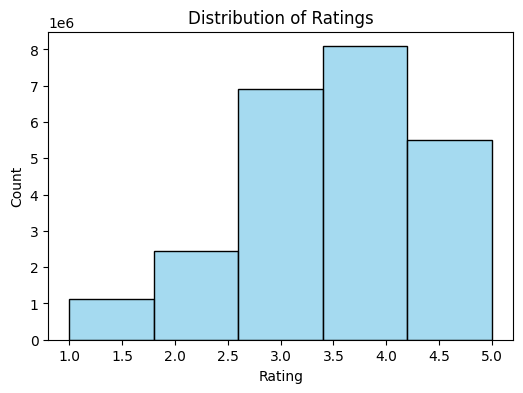

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['rating'], bins=5, kde=False, color='skyblue')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

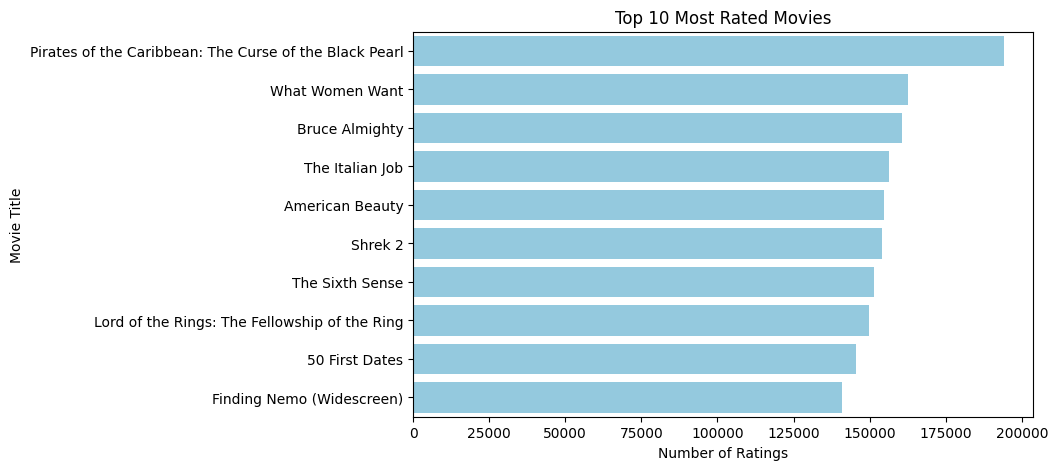

In [ ]:
top10_popular = df['title'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(y=top10_popular.index, x=top10_popular.values,color='skyblue')
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()


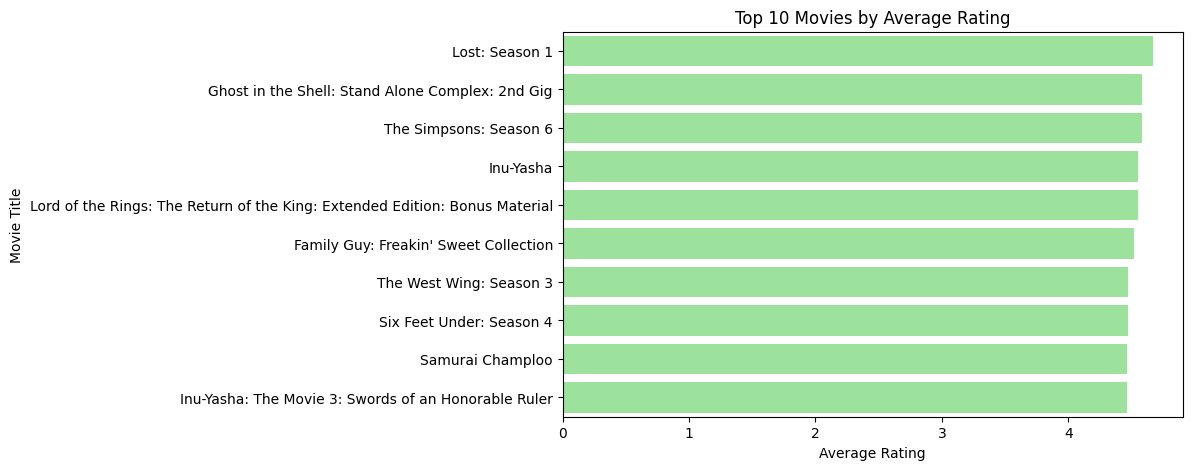

In [ ]:
avg_ratings = df.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(y=avg_ratings.index, x=avg_ratings.values, color='lightgreen')
plt.title("Top 10 Movies by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.show()


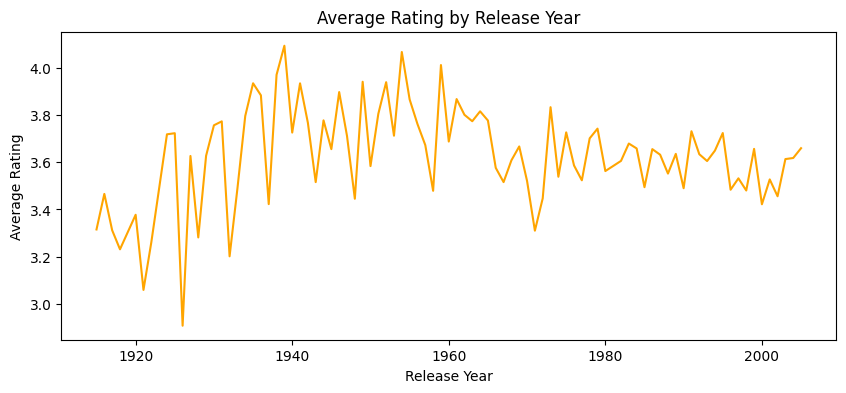

In [ ]:
avg_year = df.groupby('year')['rating'].mean().dropna()

plt.figure(figsize=(10,4))
sns.lineplot(x=avg_year.index, y=avg_year.values, color='orange')
plt.title("Average Rating by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Rating")
plt.show()


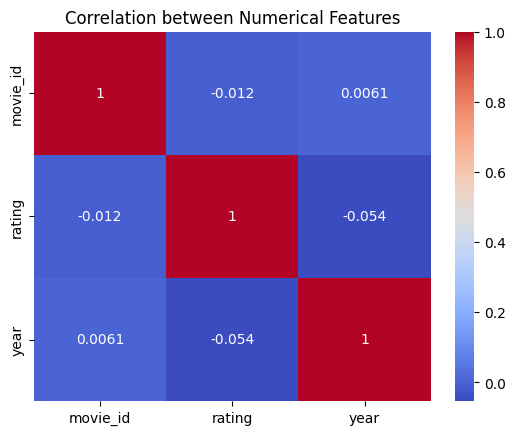

In [ ]:
corr = df[['movie_id','rating','year']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Numerical Features")
plt.show()


In [ ]:
df.shape

(24053764, 6)

In [ ]:
sample_df = df.sample(n=20000, random_state=42)
print("Sample size:", sample_df.shape)


Sample size: (20000, 6)


In [ ]:
top_movies = sample_df['title'].value_counts().head(200).index
small_df = sample_df[sample_df['title'].isin(top_movies)]
print("Reduced dataset:", small_df.shape)


Reduced dataset: (11525, 6)


In [ ]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split

reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(small_df[['user_id','movie_id','rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("✅ Data ready for SVD model (using reduced dataset).")


✅ Data ready for SVD model (using reduced dataset).


In [ ]:
#  Train and Evaluate the SVD Model
from surprise import SVD, accuracy
from surprise.model_selection import train_test_split

# 1️⃣ Initialize the SVD algorithm
svd_model = SVD()

# 2️⃣ Train on the training dataset
svd_model.fit(trainset)

# 3️⃣ Make predictions on the test dataset
predictions = svd_model.test(testset)

# 4️⃣ Evaluate performance
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

print("\n✅ Model Evaluation Complete!")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")


RMSE: 1.0108
MAE:  0.8106

✅ Model Evaluation Complete!
RMSE: 1.0108
MAE : 0.8106


In [ ]:
# STEP 9 — Generate Movie Recommendations

from collections import defaultdict
import pandas as pd

def get_top_n(predictions, n=5):
    """Return top-N recommendations for each user"""
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # sort and keep top N
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

# Build full training set for all available data
full_trainset = data.build_full_trainset()
svd_model.fit(full_trainset)

# Build anti-testset (all movies not yet rated by a user)
testset_full = full_trainset.build_anti_testset()

# Predict for all unseen items
predictions_full = svd_model.test(testset_full)

# Get top 5 recommendations per user
top_n = get_top_n(predictions_full, n=5)

print("✅ Top-N recommendations generated successfully!")


✅ Top-N recommendations generated successfully!


In [ ]:
#  Display Top-N Movie Recommendations for a Sample User

def show_recommendations(user_id, top_n_dict, titles_df):
    """Display top-N recommended movies for a given user."""
    if user_id not in top_n_dict:
        print("No recommendations found for this user.")
        return

    recs = pd.DataFrame(top_n_dict[user_id], columns=['movie_id', 'predicted_rating'])
    recs = recs.merge(titles_df[['movie_id', 'title']], on='movie_id', how='left')

    print(f"\n🎥 Top 5 Recommended Movies for User {user_id}:")
    display(recs[['title', 'predicted_rating']])

# pick a random user from the dataset
example_user = list(top_n.keys())[0]
show_recommendations(example_user, top_n, titles_df)



🎥 Top 5 Recommended Movies for User 1934293:


,title,predicted_rating
0,Braveheart,4.484407
1,Batman Begins,4.439093
2,The Silence of the Lambs,4.426825
3,Finding Nemo (Widescreen),4.357106
4,Aladdin: Platinum Edition,4.354517


In [ ]:
# Hyper-parameter tuning for SVD
from surprise import SVD
from surprise.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_factors': [50, 100, 150],
    'lr_all': [0.002, 0.005, 0.007],
    'reg_all': [0.02, 0.05, 0.1]
}

# Perform 3-fold cross-validation
gs = GridSearchCV(SVD, param_grid, measures=['rmse','mae'], cv=3, n_jobs=-1)
gs.fit(data)

# Display best results
print("✅ Grid Search Complete!")
print(f"Best RMSE score: {gs.best_score['rmse']:.4f}")
print("Best Parameters:", gs.best_params['rmse'])


✅ Grid Search Complete!
Best RMSE score: 1.0004
Best Parameters: {'n_factors': 50, 'lr_all': 0.005, 'reg_all': 0.1}


In [ ]:
#Retrain final optimized model
best_params = gs.best_params['rmse']
final_model = SVD(**best_params)

final_model.fit(trainset)
predictions = final_model.test(testset)

from surprise import accuracy
accuracy.rmse(predictions)
accuracy.mae(predictions)


RMSE: 1.0102
MAE:  0.8109


0.81090840941479